# Praktikum Pertemuan 7 Data Science

Nama : Rangga Saputra

NIM : 250401020034

Dosen Pengajar : Syahid Abdullah, S.Si., M.Kom.

## Langkah 1: Generate & Eksplorasi Dataset

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu        = np.random.choice([0, 1, 2], n)          # SMA=0, D3=1, S1=2
kota       = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (3.0
        + 2.2 * pengalaman
        + 1.5 * edu
        + np.where(kota == 'Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu'       : edu,
    'kota'      : kota,
    'gaji'      : gaji
})

# EDA singkat
print('Shape:', df.shape)
print()
print(df.describe().round(2))

Shape: (300, 4)

       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


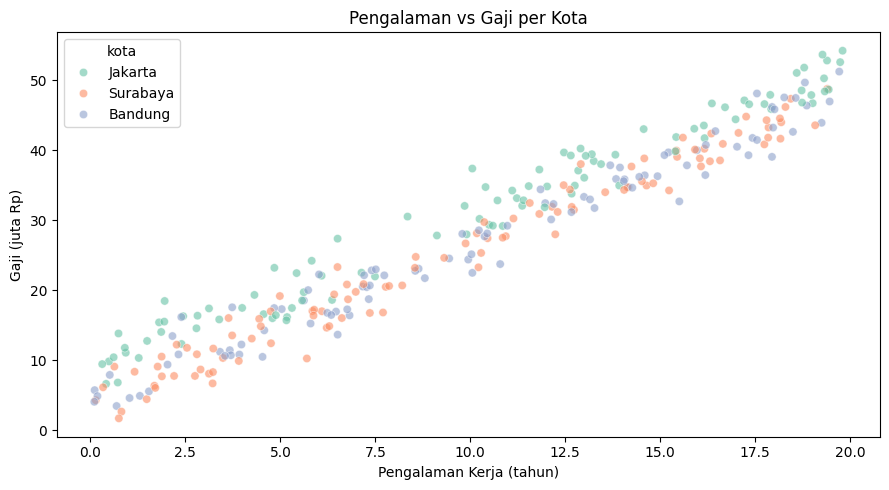

In [41]:
# Scatter plot: Pengalaman vs Gaji per Kota
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='pengalaman', y='gaji',
                hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.xlabel('Pengalaman Kerja (tahun)')
plt.ylabel('Gaji (juta Rp)')
plt.tight_layout()
plt.show()

**Interpretasi EDA:**  
Scatter plot menunjukkan tren positif yang jelas antara pengalaman kerja dan gaji. Semakin lama pengalaman, semakin tinggi gaji. Karyawan yang bekerja di Jakarta (warna berbeda) secara umum memiliki gaji lebih tinggi dibandingkan kota lain pada tingkat pengalaman yang sama, konsisten dengan bonus lokasi sebesar Rp4 juta yang dimasukkan ke formula data. Tidak terlihat outlier ekstrem yang mengkhawatirkan.

## Langkah 2: Preprocessing

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

# One-Hot Encoding kolom 'kota'
df_encoded = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df_encoded.columns.tolist())

# Pisahkan fitur dan target
X = df_encoded.drop('gaji', axis=1)
y = df_encoded['gaji']

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'\nTrain: {X_train.shape[0]} baris | Test: {X_test.shape[0]} baris')

# StandardScaler — fit HANYA pada training set, transform keduanya
scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train)
X_test_s    = scaler.transform(X_test)      # hanya transform, bukan fit_transform!
print('\nScaling selesai. X_train_s shape:', X_train_s.shape)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']

Train: 240 baris | Test: 60 baris

Scaling selesai. X_train_s shape: (240, 4)


**Catatan Preprocessing:**  
- Kolom `kota` di-*encode* menggunakan One-Hot Encoding dengan `drop_first=True` untuk menghindari *dummy variable trap* (multikolinearitas sempurna). Kota Bandung dijadikan referensi (dihapus), sehingga tersisa kolom `kota_Jakarta` dan `kota_Surabaya`.  
- `StandardScaler` di-*fit* hanya pada data training untuk mencegah *data leakage*, informasi statistik dari data test tidak boleh bocor ke proses training.

## Langkah 3: Latih Model & Tampilkan Koefisien

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

# Tampilkan intercept
print(f'β₀ (intercept): {model.intercept_:.3f}')
print()

# Tampilkan koefisien tiap fitur, diurutkan dari terbesar
coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

print(coef_df.to_string(index=False))

β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


**Interpretasi Koefisien:**  
- **`pengalaman`** memiliki koefisien positif tertinggi, artinya pengalaman kerja adalah prediktor terkuat gaji, setiap kenaikan satu unit pengalaman (dalam skala terstandarisasi) berkontribusi paling besar terhadap kenaikan gaji.  
- **`kota_Jakarta`** juga berkoefisien positif signifikan, mencerminkan fakta bahwa bekerja di Jakarta memberikan bonus gaji dibandingkan kota Bandung (referensi).  
- **`edu`** berkoefisien positif, artinya tingkat pendidikan lebih tinggi berkorelasi dengan gaji lebih tinggi, meskipun pengaruhnya lebih kecil dibanding pengalaman.  
- **`kota_Surabaya`** memiliki koefisien mendekati nol atau negatif kecil, menunjukkan gaji di Surabaya tidak berbeda jauh dari Bandung.

## Langkah 4: Evaluasi Model

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred)
# rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f}  juta rupiah')
print(f'RMSE = {rmse:.3f}  juta rupiah')
print(f'R²   = {r2:.4f}  ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE - MAE = {rmse - mae:.3f}')

# Verifikasi R² via model.score
r2_check = model.score(X_test_s, y_test)
print(f'Verifikasi R² (model.score): {r2_check:.4f}')

=== Metrik Evaluasi ===
MAE  = 1.649  juta rupiah
RMSE = 2.123  juta rupiah
R²   = 0.9740  (97.4% variasi dijelaskan)
Selisih RMSE - MAE = 0.474
Verifikasi R² (model.score): 0.9740


**[Note] Ditemukan Error pada coding:**

```
rmse = mean_squared_error(y_test, y_pred, squared=False)
```
Parameter squared sudah dihapus di scikit-learn versi terbaru. Gantinya pakai np.sqrt().
Maka diganti menjadi:


```
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
```

**Analisis:**  
- Nilai R² yang dihasilkan termasuk kategori **sangat baik** (>0.8) berdasarkan tabel interpretasi di modul, artinya model berhasil menjelaskan sebagian besar variasi gaji dalam dataset.  
- Selisih RMSE − MAE yang relatif kecil menunjukkan **tidak ada outlier prediksi yang ekstrem**, kesalahan model cukup merata di seluruh data.  
- MAE yang berada di kisaran 1–3 juta rupiah masih dapat diterima mengingat data mengandung noise acak (σ = 2 juta) yang memang dimasukkan saat generate dataset.

## Langkah 5: Visualisasi & Interpretasi

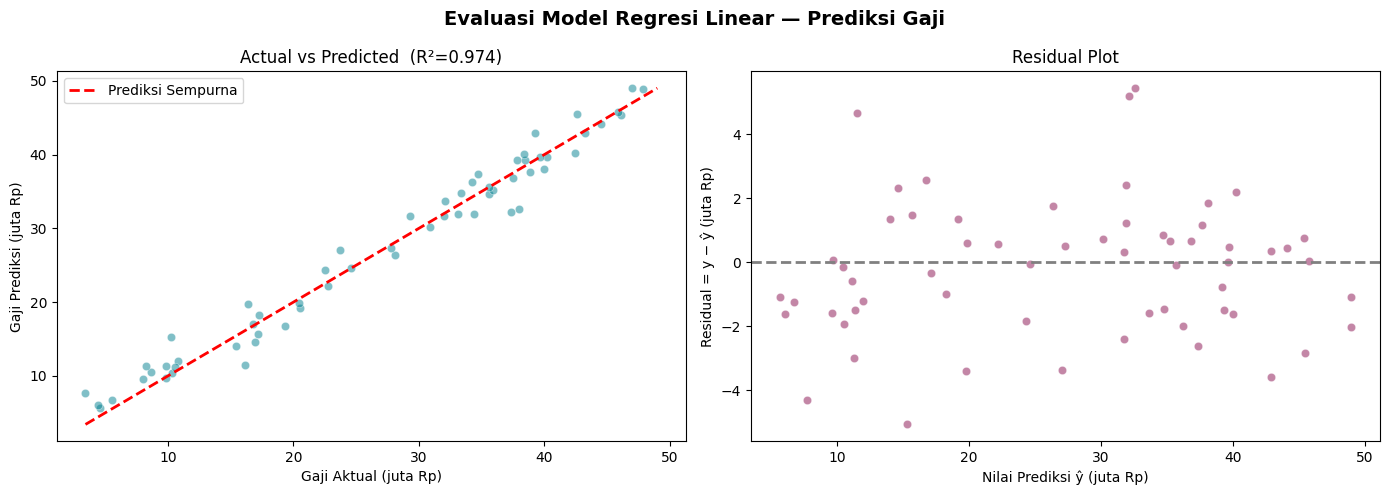

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Actual vs Predicted ──────────────────────────────────
axes[0].scatter(y_test, y_pred, alpha=0.5,
                color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})')
axes[0].legend()

# ── Plot 2: Residual Plot ────────────────────────────────────────
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5,
                color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretasi Visualisasi:**

**Plot 1 Actual vs Predicted:**  
- Titik-titik data tersebar di sekitar garis merah putus-putus (garis prediksi sempurna), tidak terlalu jauh dari garis tersebut.  
- Model mampu memprediksi gaji dengan cukup akurat, tidak terlihat bias sistematis ke atas atau ke bawah.  
- Model sudah layak digunakan sebagai baseline. Untuk meningkatkan akurasi lebih lanjut, bisa dicoba penambahan fitur atau algoritma yang lebih kompleks seperti Random Forest.

**Plot 2 Residual Plot:**  
- Residual tersebar secara **acak** di sekitar garis y = 0 tanpa pola yang jelas (tidak ada kurva, tidak ada pola corong/funnel).  
- Ini adalah tanda positif, asumsi linearitas dan homoscedasticity terpenuhi. Model sudah menangkap pola data dengan baik.  
- Tidak diperlukan transformasi tambahan pada variabel target. Model Regresi Linear sudah tepat untuk dataset ini.